In [30]:
import matplotlib, time, copy
import autograd.numpy as np
import autograd.scipy.stats as sps_autograd
from autograd import grad, hessian, jacobian
from statsmodels.tsa.arima_process import ArmaProcess
from scipy.optimize import minimize
from scipy.linalg import toeplitz
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt 
from pymc3 import ess as effective_sample_size

In [2]:
"""
Simulate ARMA(1, 1) model
"""
theta0 = np.array([0.5, 0.2, 2]) # True parameter values

# Define AR and MA coefficients
ar = np.array([1, -theta0[0]])  
ma = np.array([1, -theta0[1]])         

# Create ARMA process object
arma_process = ArmaProcess(ar, ma)

# Simulate 500 samples
n = 10000
y = arma_process.generate_sample(nsample=n, scale=theta0[2]) # scale is the variance of the white noise

In [3]:
def initiate_KF_parameter_values(theta):
    """
    Initialise the parameters for the Kalman Filter
    """
    # Initial values for Kalman Filter
    a, b, sgm = theta
    k = 2

    # Simple operations that autograd can handle
    F = np.array([[a, 1.0], [0.0, 0.0]])
    G = np.array([[1.0], [-b]]).reshape(2,1)
    H = np.array([[1.0, 0.0]]).reshape(1,2)
    Q = sgm ** 2

    # Gradient parts

    # Declare the gradient of F
    dF = np.zeros((3, 1, 2, 2))
    dF[0, 0, 0, 0] = 1.0

    # Declare the gradient of G
    dG = np.zeros((3, 1, 2, 1))
    dG[1, 0, 1, 0] = -1.0

    dH = np.zeros((3, 1, 1, 2))

    # Declare the gradient of Q
    dQ = np.zeros((3, 1, 1, 1))
    dQ[2, 0, 0, 0] = 2 * sgm
    
    # Compute the initial value of covariance matrix V
    g = np.array([1.0, a - b, a * (a - b)])

    C = np.array([
        sgm**2 * (1 - 2 * a * b + b**2) / (1 - a**2),
        a * (sgm**2 * (1 - 2 * a * b + b**2) / (1 - a**2)) - sgm**2 * b,
        a * (a * (sgm**2 * (1 - 2 * a * b + b**2) / (1 - a**2)) - sgm**2 * b)
    ])

    dV = np.zeros((3, 1, 2, 2))
    V = np.array([
        [C[0], -b * g[0]],
        [-b * g[0], b**2 * sgm**2]
    ])

    dVa = np.array([
        [(2 * sgm**2 * (a-b) * (1 - a*b)) / (1 - a**2)**2, 0],
        [0, 0]
    ])
    dVb = np.array([
        [2 * sgm**2 * (b-a) / (1 - a**2), -1],
        [-1, 2 * b * sgm**2]
    ])
    dVs = np.array([
        [2 * sgm * (1 - 2 * a * b + b**2) / (1 - a**2), 0],
        [0, 2 * b**2 * sgm]
    ])

    dV[0, 0, :, :] = dVa
    dV[1, 0, :, :] = dVb
    dV[2, 0, :, :] = dVs


    # Hessian parts

    # Declare the Hessian of F, G, H, Q
    d2F = np.zeros((3, 3, 2, 2))
    d2G = np.zeros((3, 3, 2, 1))
    d2H = np.zeros((3, 3, 1, 2))
    d2Q = np.zeros((3, 3, 1, 1))
    d2Q[2, 2, 0, 0] = 2

    # Declare the Hessian of covariance matrix V
    d2V = np.zeros((3, 3, 2, 2))

    d2V[0, 0, 0, 0] = -2*(-1 + 6*a*b + 2*a**3 *b - b**2 - 3* a**2 *(1+b**2)) * (sgm**2) / ((1-a**2)**3)
    d2V[0, 1, 0, 0] = -2 * (1 + a**2 - 2*a*b) * (sgm**2) / ((1-a**2)**2)
    d2V[0, 2, 0, 0] = -4 * (b + a**2 * b - a*(1+b**2)) * sgm / (1-a**2)**2

    d2V[1, 1, 0, 0] = 2*sgm**2 / (1-a**2)
    d2V[1, 1, 1, 1] = 2*sgm**2

    d2V[1, 2, 0, 0] = 2*sgm*(-2 * a + 2 * b) / (1-a**2)
    d2V[1, 2, 1, 1] = 4*b*sgm
    
    d2V[2, 2, 0, 0] = 2*(1-2*a*b + b**2) / (1-a**2)
    d2V[2, 2, 1, 1] = 2 * b**2
    
    # Copy the same Hessian
    d2V[1, 0, :, :] = d2V[0, 1, :, :].copy()
    d2V[2, 0, :, :] = d2V[0, 2, :, :].copy()
    d2V[2, 1, :, :] = d2V[1, 2, :, :].copy()

    # Initialize the x and dx
    x = np.zeros((k, 1))
    dx = np.zeros((3, 1, 2, 1))
    d2x = np.zeros((3, 3, 2, 1))

    return F, G, H, Q, dF, dG, dH, dQ, d2F, d2G, d2H, d2Q, V, dV, d2V, x, dx, d2x, k


In [ ]:
def analytical_grad_hess(theta, y):

    # Initialize the parameters
    F, G, H, Q, dF, dG, dH, dQ, d2F, d2G, d2H, d2Q, V, dV, d2V, x, dx, d2x, k = initiate_KF_parameter_values(theta)

    # Dictionary to store the values
    dict = {
        'log_likelihood_t': [],
        'analytical_grad_t': [],
        'analytical_Hess_t': [],
    }

    N = len(y)

    # Run the Kalman filter for gradient
    for t in range(N):
        
        # 1. PREDICT
        # Predict one-step-ahead state predictive density of x_{t}
        x_predict = F @ x
        V_predict = F @ V @ F.T + G * Q @ G.T

        # Compute forecast error and one-step-ahead predictive variance
        e_t = y[t] - (H @ x_predict)[0, 0]
        r_t = (H @ V_predict @ H.T)[0, 0]

        # Kalman filter for gradient
        dx_predict = F @ dx + dF @ x
        dV_predict = F @ dV @ F.T + dF @ V @ F.T + F @ V @ dF + G @ dQ @ G.T + dG * Q @ G.T + G * Q @ dG.reshape(3, 1, 1, 2)
        d2x_predict = (dF @ dx.reshape(1, 3, 2, 1)) + (dF @ dx.reshape(1, 3, 2, 1)).swapaxes(0, 1) \
                    + F @ d2x \
                    + d2F @ x
        d2V_predict = (dF @ dV.reshape(1, 3, 2, 2) @ F.T) + (dF @ dV.reshape(1, 3, 2, 2) @ F.T).swapaxes(0, 1) \
                    + F @ d2V @ F.T \
                    + (F @ dV @ dF.reshape(1, 3, 2, 2)) + (F @ dV @ dF.reshape(1, 3, 2, 2)).swapaxes(0, 1) \
                    + d2F @ V @ F.T \
                    + (dF @ V @ dF.reshape(1, 3, 2, 2)) + (dF @ V @ dF.reshape(1, 3, 2, 2)).swapaxes(0, 1) \
                    + F @ V @ d2F\
                    + (dG @ dQ.reshape(1, 3, 1, 1) @ G.T) + (dG @ dQ.reshape(1, 3, 1, 1) @ G.T).swapaxes(0, 1) \
                    + G @ d2Q @ G.T \
                    + (G @ dQ @ dG.reshape(1, 3, 1, 2)) + (G @ dQ @ dG.reshape(1, 3, 1, 2)).swapaxes(0, 1) \
                    + d2G * Q @ G.T \
                    + (dG * Q @ dG.reshape(1, 3, 1, 2)) + (dG * Q @ dG.reshape(1, 3, 1, 2)).swapaxes(0, 1) \
                    + G * Q @ d2G.reshape(3, 3, 1, 2) 

        # Calculate gradient and Hessian of e_t and r_t
        de_t = -H @ dx_predict
        dr_t = H @ dV_predict @ H.T
        d2e_t = - (dH @ dx_predict.reshape(1, 3, 2, 1)) - (dH @ dx_predict.reshape(1, 3, 2, 1)).swapaxes(0, 1) \
                - H @ d2x_predict \
                - d2H @ x_predict
        d2r_t = (dH @ dV_predict.reshape(1, 3, 2, 2) @ H.T) + (dH @ dV_predict.reshape(1, 3, 2, 2) @ H.T).swapaxes(0, 1) \
                + H @ d2V_predict @ H.T \
                + (H @ dV_predict @ dH.reshape(1, 3, 2, 1)) + (H @ dV_predict @ dH.reshape(1, 3, 2, 1)).swapaxes(0, 1) \
                + d2H @ V_predict @ H.T \
                + 2 * (dH @ V_predict @ dH.reshape(1, 3, 2, 1))  \
                + H @ V_predict @ d2H.reshape(3, 3, 2, 1) 


        # 2. UPDATE
        # Kalman gain
        K = V_predict @ H.T / r_t
        dK = (dV_predict @ H.T / r_t) - (V_predict @ H.T / r_t**2) @ dr_t
        d2K = (d2V_predict @ H.T 
                + (dV_predict @ dH.reshape(1, 3, 2, 1)) + (dV_predict @ dH.reshape(1, 3, 2, 1)).swapaxes(0, 1)
                + V_predict @ d2H.reshape(3, 3, 2, 1)) * (1/r_t) \
            - (dV_predict @ H.T + V_predict @ dH.reshape(3, 1, 2, 1)) * (1/r_t**2) @ dr_t.reshape(1, 3, 1, 1) \
            - ((dV_predict @ H.T + V_predict @ dH.reshape(3, 1, 2, 1)) * (1/r_t**2) @ dr_t.reshape(1, 3, 1, 1)).swapaxes(0, 1) \
            + (V_predict @ H.T) * (1/r_t**3) @ dr_t @ dr_t.reshape(1, 3, 1, 1) \
            + ((V_predict @ H.T) * (1/r_t**3) @ dr_t @ dr_t.reshape(1, 3, 1, 1)).swapaxes(0, 1) \
            - V_predict @ H.T * (1/r_t**2) @ d2r_t 

        # Update current state and covariance
        x = x_predict + K * e_t
        V = (np.eye(k) - K @ H) @ V_predict

        # Update dx and dV
        dx = dx_predict + K @ de_t + dK * e_t
        dV = dV_predict - dK @ H @ V_predict - K @ H @ dV_predict
        d2x = d2x_predict \
            + (dK @ de_t.reshape(1, 3, 1, 1)) + (dK @ de_t.reshape(1, 3, 1, 1)).swapaxes(0, 1) \
            + K @ d2e_t \
            + d2K * e_t
        d2V = d2V_predict \
            - d2K @ H @ V_predict \
            - (dK @ dH.reshape(1, 3, 1, 2) @ V_predict) - (dK @ dH.reshape(1, 3, 1, 2) @ V_predict).swapaxes(0, 1) \
            - (dK @ H @ dV_predict.reshape(1, 3, 2, 2)) - (dK @ H @ dV_predict.reshape(1, 3, 2, 2)).swapaxes(0, 1) \
            - K @ d2H @ V_predict \
            - (K @ dH @ dV_predict.reshape(1, 3, 2, 2)) - (K @ dH @ dV_predict.reshape(1, 3, 2, 2)).swapaxes(0, 1) \
            - K @ H @ d2V_predict 
        
        # Compute sigma2_hat and gradient of the log-likelihood
        log_likelihood_t = -0.5 * (
            np.log(2 * np.pi) 
            + np.log(r_t) 
            + e_t**2 / r_t
        )
        
        # Compute the gradient of the log-likelihood at the observation t
        analytical_grad_t = - 0.5 * (
            1/r_t * dr_t
            + 2 * e_t * de_t / r_t
            - e_t**2 * dr_t / r_t**2
        )
        
        # Compute the Hessian of the log-likelihood at the observation t
        analytical_Hess_t = -0.5 * (
            (1/r_t) * (1 - (e_t**2 / r_t)) * d2r_t 
            + 2 * (e_t/r_t) * d2e_t 
            + ((2 * e_t**2 / r_t**3) - (1/r_t**2)) * dr_t @ dr_t.reshape(1, 3, 1, 1)
            + (2 / r_t) * de_t @ de_t.reshape(1, 3, 1, 1)
            - 2 * (e_t / r_t**2) * (de_t @ dr_t.reshape(1, 3, 1, 1) + dr_t @ de_t.reshape(1, 3, 1, 1))
        )
        

        # Store the result
        dict['log_likelihood_t'].append(log_likelihood_t)
        dict['analytical_grad_t'].append(analytical_grad_t.flatten())
        dict['analytical_Hess_t'].append(analytical_Hess_t.squeeze())
        
    # Return the dictionary
    return dict



In [5]:
def loglikelihood_t(theta, y):

    # Initialize the parameters
    # region Initial values for Kalman Filter
    a, b, sgm = theta
    k = 2

    # Simple operations that autograd can handle
    F = np.array([[a, 1.0], [0.0, 0.0]])
    G = np.array([[1.0], [-b]]).reshape(2, 1)
    H = np.array([[1.0, 0.0]]).reshape(1, 2)
    Q = sgm ** 2

    # Compute the initial value of covariance matrix V
    g = np.array([1.0, a - b, a * (a - b)])

    C = np.array([
        sgm**2 * (1 - 2 * a * b + b**2) / (1 - a**2),
        a * (sgm**2 * (1 - 2 * a * b + b**2) / (1 - a**2)) - sgm**2 * b,
        a * (a * (sgm**2 * (1 - 2 * a * b + b**2) / (1 - a**2)) - sgm**2 * b)
    ])

    V = np.array([
        [C[0], -b * g[0]],
        [-b * g[0], b**2 * sgm**2]
    ])

    x = np.zeros((k, 1))

    log_likelihood = []

    N = len(y)

    # Run the Kalman filter for gradient
    for t in range(N):
        
        # 1. PREDICT
        # Predict one-step-ahead state predictive density of x_{t}
        x_predict = F @ x
        V_predict = F @ V @ F.T + G * Q @ G.T

        # Compute forecast error and one-step-ahead predictive variance
        e_t = y[t] - (H @ x_predict)[0, 0]
        r_t = (H @ V_predict @ H.T)[0, 0]

        # 2. UPDATE
        # Kalman gain
        K = V_predict @ H.T / r_t

        # Update current state and covariance
        x = x_predict + K * e_t
        V = (np.eye(k) - K @ H) @ V_predict

        # Compute sigma2_hat and gradient of the log-likelihood
        log_likelihood_t = -0.5 * (
            np.log(2 * np.pi) 
            + np.log(r_t) 
            + e_t**2 / r_t
        )

        log_likelihood.append(log_likelihood_t)

    # Return the dictionary
    return np.array(log_likelihood), np.sum(log_likelihood)



In [6]:
# # Initialize the parameters
# theta = np.array([-0.2, 0.1, 1.5])
# obj = analytical_grad_hess(theta)  

# # Dataframe to store the results
# df = pd.DataFrame(columns=['t', 'analytical_grad', 'autograd', 'equal'])

# for t in range(N):
#     # Analytical gradient
#     analytical_grad = obj['analytical_grad_t'][t]

#     # Autograd
#     obj_func_likelihood = lambda param: loglikelihood_t(param)[t]
#     grad_obj_func_likelihood = grad(obj_func_likelihood)
#     auto_grad_val = grad_obj_func_likelihood(theta)

#     # Store the results
#     df.loc[t, 't'] = t
#     df.loc[t, 'analytical_grad'] = analytical_grad
#     df.loc[t, 'autograd'] = auto_grad_val
#     df.loc[t, 'equal'] = np.allclose(analytical_grad, auto_grad_val)

# # Check the results
# print(sum(df['equal']) == N)
# df.tail()


In [ ]:
# # Initialize the parameters
# theta = np.array([-0.2, 0.1, 1.5])
# obj = analytical_grad_hess(theta, y=y)  

# # Dataframe to store the results
# df = pd.DataFrame(columns=['t', 'analytical_Hess', 'auto_Hess', 'equal'])

# for t in range(500):
#     # Analytical gradient
#     analytical_Hess = obj['analytical_Hess_t'][t]

#     # Autograd
#     obj_func_likelihood = lambda param: loglikelihood_t(param, y=y)[0][t]
#     Hess_obj_func_likelihood = hessian(obj_func_likelihood)
#     auto_Hess_val = Hess_obj_func_likelihood(theta)

#     # Store the results
#     df.loc[t, 't'] = t
#     df.loc[t, 'analytical_Hess'] = analytical_Hess
#     df.loc[t, 'auto_Hess'] = auto_Hess_val
#     df.loc[t, 'equal'] = np.allclose(analytical_Hess, auto_Hess_val)

# # Check the results
# print(sum(df['equal']) == 500)
# df.head()


KeyboardInterrupt: 

In [8]:
def log_prior(theta):
    """
    Simple indepent normal prior with mean 0 and variance 10^2
    """
    return np.sum(sps_autograd.norm.logpdf(theta, 0, 10**2))

In [9]:
# Define the log-posterior
log_posterior = lambda theta: loglikelihood_t(theta, y=y)[1] + log_prior(theta) 
obj_func_posterior = lambda theta: -log_posterior(theta) # For maximisation purpose
grad_obj_func_posterior = lambda theta: -np.sum(analytical_grad_hess(theta, y=y)['analytical_grad_t'], axis=0) # Gradient of obj_func_posterior
# Hess_obj_func_posterior  = hessian(obj_func_posterior) # Hessian of obj_func_posterior. Computed by automatic differentiation

# Find starting values by optimising the log-posterior
theta_optim_start = theta0
res_optim_posterior = minimize(obj_func_posterior, theta_optim_start, method='BFGS', jac=grad_obj_func_posterior, options={'gtol': 1e-04, 'maxiter': 1000, 'disp': True})

# Compare answers
print('True parameter values')
print(theta0)
print('MAP estimates')
MAP = res_optim_posterior.x
print(np.round(MAP, 2))

# Control variate expanded around this
thetaStar = MAP 


Optimization terminated successfully.
         Current function value: 21114.852297
         Iterations: 7
         Function evaluations: 10
         Gradient evaluations: 10
True parameter values
[0.5 0.2 2. ]
MAP estimates
[0.54 0.25 2.  ]


In [10]:
def initiate_control_variate_quantities(thetaStar):
    """
    Creates the quantities needed to construct the second order parameter expanded Taylor control variates for the log_density.
    Output from this function will go into the function eval_q_k
    """
    n = len(y)
    p = len(thetaStar)

    # Declare the output 
    dens_at_thetaStar = np.zeros(n)
    grad_at_thetaStar = np.zeros([n, p])
    Hess_at_thetaStar = np.zeros([n, p, p])

    # Run the Kalman filter for gradient
    analytical_grad_hess_result = analytical_grad_hess(thetaStar, y=y)
    dens_at_thetaStar = analytical_grad_hess_result['log_likelihood_t']
    grad_dens = analytical_grad_hess_result['analytical_grad_t']
    Hess_dens = analytical_grad_hess_result['analytical_Hess_t']
    
    for i in range(n):    
        if i % 1000 == 0:
            print("Processed %s observations (out of % s)" % (i, n))

        grad_at_thetaStar[i, :], Hess_at_thetaStar[i, :] = grad_dens[i], Hess_dens[i]
                    
    return np.array(dens_at_thetaStar), np.array(grad_at_thetaStar), np.array(Hess_at_thetaStar)

In [11]:
dens_at_thetaStar_ARMA, grad_at_thetaStar_ARMA, Hess_at_thetaStar_ARMA = initiate_control_variate_quantities(thetaStar)

Processed 0 observations (out of 10000)
Processed 1000 observations (out of 10000)
Processed 2000 observations (out of 10000)
Processed 3000 observations (out of 10000)
Processed 4000 observations (out of 10000)
Processed 5000 observations (out of 10000)
Processed 6000 observations (out of 10000)
Processed 7000 observations (out of 10000)
Processed 8000 observations (out of 10000)
Processed 9000 observations (out of 10000)


In [12]:
def eval_q_k(theta, dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar, order = 2):
    """
    Evaluates the order order parameter expanded Taylor control variates at the point theta for all observations in 
    dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar. Default order is 2.
    """
    const_term = dens_at_thetaStar
    if order == 0:
        q_k = const_term
    elif order == 1:
        first_term = np.sum(grad_at_thetaStar*(theta - thetaStar), axis = 1)
        q_k = const_term + first_term
    elif order == 2:
        first_term = np.sum(grad_at_thetaStar*(theta - thetaStar), axis = 1)
        second_term = 0.5*np.sum(np.sum(Hess_at_thetaStar*np.outer(theta - thetaStar, theta - thetaStar), axis = 1), axis = 1)    
        q_k = const_term + first_term + second_term
    else:
        raise ValueError("Order must be 0 <= order <= 2")
    return q_k

Estimate
-21098.96592485859
True value
-21098.96648511076
Subsampling MCMC for the ARMA(1,1) model with n = 10000, m = 100, G = 10 and Taylor order = 2
Iteration i = 1000. Acceptance prob (mean) 0.29. Time: 100.47
Iteration i = 2000. Acceptance prob (mean) 0.30. Time: 205.01
Iteration i = 3000. Acceptance prob (mean) 0.31. Time: 311.31
Iteration i = 4000. Acceptance prob (mean) 0.31. Time: 419.56
Iteration i = 5000. Acceptance prob (mean) 0.31. Time: 525.84
Iteration i = 6000. Acceptance prob (mean) 0.32. Time: 633.38
Iteration i = 7000. Acceptance prob (mean) 0.32. Time: 740.67
Iteration i = 8000. Acceptance prob (mean) 0.32. Time: 846.95
Iteration i = 9000. Acceptance prob (mean) 0.32. Time: 959.04
Iteration i = 10000. Acceptance prob (mean) 0.32. Time: 1076.88
Iteration i = 11000. Acceptance prob (mean) 0.32. Time: 1191.91
Iteration i = 12000. Acceptance prob (mean) 0.32. Time: 1299.14
Iteration i = 13000. Acceptance prob (mean) 0.32. Time: 1406.62
Iteration i = 14000. Acceptance pr

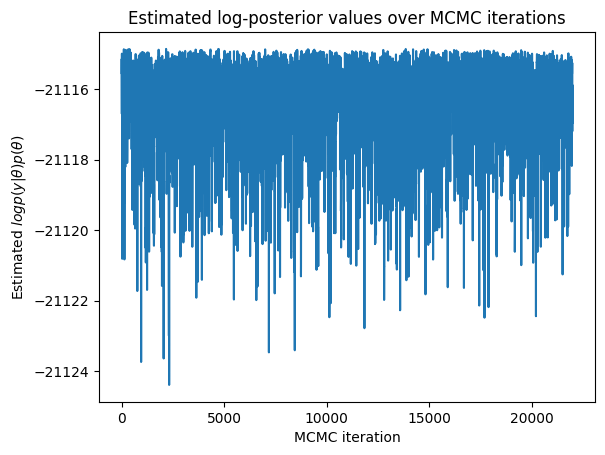

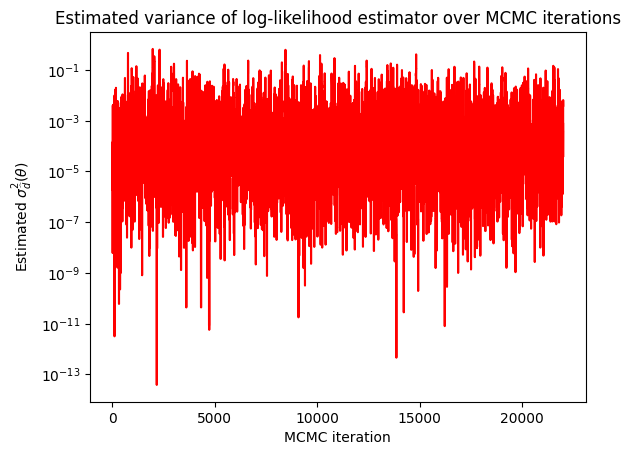

In [13]:
dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar = dens_at_thetaStar_ARMA, grad_at_thetaStar_ARMA, Hess_at_thetaStar_ARMA

d = len(thetaStar)

obj_log_prior = lambda theta: log_prior(theta)
Hess_log_prior = hessian(obj_log_prior)

# Proposal covariance
Sigma_pi = np.linalg.inv(-np.sum(Hess_at_thetaStar, axis = 0) - Hess_log_prior(thetaStar)) # Negative Hessian inverse evaluated at the mode
PropCov = 2.38**2/d*Sigma_pi

# Get ready for pseudo marginal Metropolis-Hastings sampling
Taylor_order = 2
N_sim = 22000 # MCMC samples
G = 10 # Number of blocks
m = 100 # Subsample size
u_c = np.random.randint(0, n, m)
u_block_indicators = np.hstack((np.repeat(np.arange(G-1), m/G), np.repeat(G-1, m - len(np.repeat(np.arange(G-1), m/G))))) # Splits the u into blocks

# Precomputed quantities for the control variates that do not depend on theta
# Following the notation in the slides
A = np.sum(dens_at_thetaStar) 
B = np.sum(grad_at_thetaStar, axis = 0)
C = np.sum(Hess_at_thetaStar, axis = 0)

if Taylor_order == 0:
    q_sum = lambda theta: A
elif Taylor_order == 1:
    q_sum = lambda theta: A + np.dot(B, theta - thetaStar)
elif Taylor_order == 2:
    q_sum = lambda theta: A + np.dot(B, theta - thetaStar) + 0.5*np.dot(theta - thetaStar, np.dot(C, theta - thetaStar))
else:
    raise NotImplementedError

# Storage
theta_init = MAP + sps.norm.rvs(0, 0.01, len(MAP))
samples = np.zeros((N_sim + 1, d))
samples[0, :] = theta_init
alphas = np.zeros(N_sim)
log_posthat_samples = np.zeros(N_sim + 1) # Keeps the estimated value of the log-posterior (up to a normalisation constant)
sigma2_lhat_samples = np.zeros(N_sim + 1) # Keeps the estimated variance of the log-likelihood estimator 

# Current parameter and evaluate quantities
theta_c = theta_init   
u_c_max = np.max(u_c)
l_k_c = loglikelihood_t(theta_c,y=y[:u_c_max+1])[0][u_c]

q_k_c = eval_q_k(theta_c, dens_at_thetaStar[u_c], grad_at_thetaStar[u_c], Hess_at_thetaStar[u_c], order = Taylor_order)  # control variates at current theta, u
log_posthat_c = q_sum(theta_c) + n*np.mean(l_k_c - q_k_c) + log_prior(theta_c)
sigma2_lhat_c = n**2/m*np.var(l_k_c - q_k_c, ddof = 1)
log_posthat_samples[0] = log_posthat_c
sigma2_lhat_samples[0] = sigma2_lhat_c

# Check
print('Estimate')
print(q_sum(theta_c) +  n*np.mean(l_k_c - q_k_c))
print('True value')
print(loglikelihood_t(theta_c, y=y)[1])

tic = time.time()
print('Subsampling MCMC for the ARMA(1,1) model with n = %s, m = %s, G = %s and Taylor order = %s' % (n, m, G, Taylor_order))
for i in range(1, N_sim + 1):

    if i % 1000 == 0:
        print("Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}".format(i , np.mean(alphas[:i]), time.time() - tic))

    # Propose parameter vector and subsample
    theta_p = np.random.multivariate_normal(theta_c, PropCov, size = 1).flatten() # flatten() to get 1-dim array 
    
    block_to_update = np.random.randint(0, G, 1)[0]
    u_p = copy.copy(u_c)
    indices_to_update = (u_block_indicators == block_to_update)
    u_p[indices_to_update] = np.random.randint(0, n, np.sum(indices_to_update)) 
    
    # TODO: 
    # 1. Evaluate log densities and control variates at theta_p, u_p. 
    # 2. Estimate the log-likelihood and the variance of the log-likelihood
    u_p_max = np.max(u_p)
    l_k_p = loglikelihood_t(theta_p,y=y[:u_p_max+1])[0][u_p]
    q_k_p = eval_q_k(theta_p, dens_at_thetaStar[u_p], grad_at_thetaStar[u_p], Hess_at_thetaStar[u_p], order = Taylor_order) # '?' # Your code instead of '?'  # control variates at proposed theta, u
    log_posthat_p = q_sum(theta_p) + n*np.mean(l_k_p - q_k_p) + log_prior(theta_p) # '?' # Your code instead of '?' # log-likelihood estimator at proposed theta, u
    sigma2_lhat_p = n**2/m*np.var(l_k_p - q_k_p, ddof = 1) # '?' # Your code instead of '?' # estimate of variance of log-likelihood estimator at proposed theta, u
    
    # log proposal densities
    log_q_p = sps.multivariate_normal.logpdf(theta_p, mean = theta_c, cov = PropCov) # log-proposal density. Symmetric (cancels), but leave for completeness           
    log_q_c = sps.multivariate_normal.logpdf(theta_c, mean = theta_p, cov = PropCov)   
    
    alpha = np.min([1, np.exp(log_posthat_p - sigma2_lhat_p/2  - log_q_p - (log_posthat_c - sigma2_lhat_c/2 - log_q_c))])
    alphas[i - 1] = alpha
    if np.random.rand() < alpha: # sample Unif(0, 1) to determine acceptance
        samples[i, :] = theta_p
        log_posthat_samples[i] = log_posthat_p 
        sigma2_lhat_samples[i] = sigma2_lhat_p
        # Proposed becomes current in next iteration
        theta_c, log_posthat_c, sigma2_lhat_c, log_q_c, u_c = theta_p, log_posthat_p, sigma2_lhat_p, log_q_p, u_p
    else:
        samples[i, :] = theta_c 
        log_posthat_samples[i] = log_posthat_c 
        sigma2_lhat_samples[i] = sigma2_lhat_c


matplotlib.rc('text', usetex = False)  # Can set to True if want to use LaTeX
fig, ax = plt.subplots()
ax.plot(log_posthat_samples)
ax.set(xlabel='MCMC iteration', ylabel= r'Estimated $log p(y|\theta)p(\theta)$' , 
       title= 'Estimated log-posterior values over MCMC iterations')

fig, ax = plt.subplots()
ax.plot(sigma2_lhat_samples, color = 'red')
ax.set(xlabel='MCMC iteration', ylabel= r'Estimated $\sigma^2_{\widehat{d}}(\theta)$' , 
       title= 'Estimated variance of log-likelihood estimator over MCMC iterations')
ax.set_yscale('log')

# Use 2000 as burn-in
samples = samples[2000:] 

# Effective sample size and inefficiency factors
ESS = np.zeros(samples.shape[1])
for j in range(samples.shape[1]):
    ESS[j] = effective_sample_size(samples[:, j])    
IF = samples.shape[0]/ESS
   
print("Mean ESS: {:.2f}. Median ESS: {:.2f}. Min ESS: {:.2f}. Max ESS: {:.2f}".format(np.mean(ESS), np.median(ESS), np.min(ESS), np.max(ESS)))
print("Mean IF : {:.2f}. Median IF : {:.2f}. Min IF : {:.2f}. Max IF : {:.2f}".format(np.mean(IF), np.median(IF), np.min(IF), np.max(IF)))


Estimate
-21098.547746427677
True value
-21098.497918682595
Subsampling MCMC for the ARMA(1,1) model with n = 10000, m = 100, G = 10 and Taylor order = 1
Iteration i = 1000. Acceptance prob (mean) 0.29. Time: 102.40
Iteration i = 2000. Acceptance prob (mean) 0.30. Time: 204.25
Iteration i = 3000. Acceptance prob (mean) 0.31. Time: 305.58
Iteration i = 4000. Acceptance prob (mean) 0.31. Time: 407.11
Iteration i = 5000. Acceptance prob (mean) 0.31. Time: 508.83
Iteration i = 6000. Acceptance prob (mean) 0.32. Time: 610.04
Iteration i = 7000. Acceptance prob (mean) 0.32. Time: 711.30
Iteration i = 8000. Acceptance prob (mean) 0.32. Time: 813.03
Iteration i = 9000. Acceptance prob (mean) 0.32. Time: 915.88
Iteration i = 10000. Acceptance prob (mean) 0.32. Time: 1023.58
Iteration i = 11000. Acceptance prob (mean) 0.32. Time: 1131.13
Iteration i = 12000. Acceptance prob (mean) 0.32. Time: 1240.09
Iteration i = 13000. Acceptance prob (mean) 0.32. Time: 1349.06
Iteration i = 14000. Acceptance 

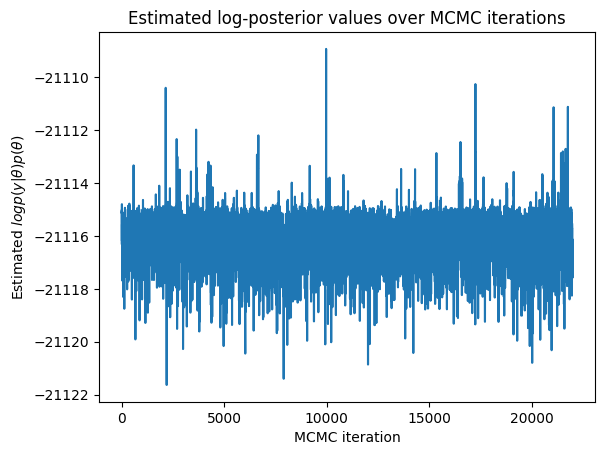

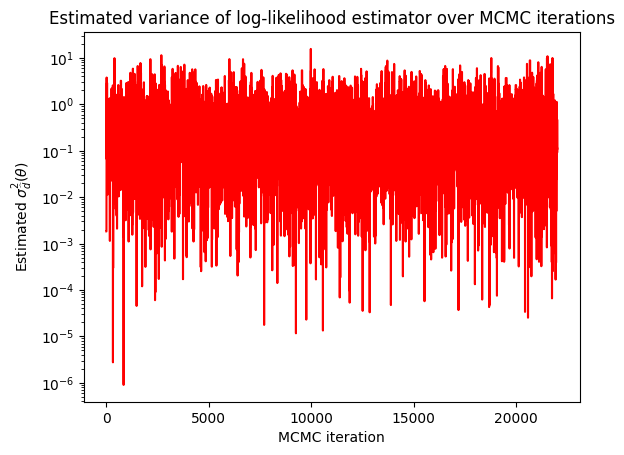

In [14]:
dens_at_thetaStar, grad_at_thetaStar, Hess_at_thetaStar = dens_at_thetaStar_ARMA, grad_at_thetaStar_ARMA, Hess_at_thetaStar_ARMA

d = len(thetaStar)

obj_log_prior = lambda theta: log_prior(theta)
Hess_log_prior = hessian(obj_log_prior)

# Proposal covariance
Sigma_pi = np.linalg.inv(-np.sum(Hess_at_thetaStar, axis = 0) - Hess_log_prior(thetaStar)) # Negative Hessian inverse evaluated at the mode
PropCov = 2.38**2/d*Sigma_pi

# Get ready for pseudo marginal Metropolis-Hastings sampling
Taylor_order = 1
N_sim = 22000 # MCMC samples
G = 10 # Number of blocks
m = 100 # Subsample size
u_c = np.random.randint(0, n, m)
u_block_indicators = np.hstack((np.repeat(np.arange(G-1), m/G), np.repeat(G-1, m - len(np.repeat(np.arange(G-1), m/G))))) # Splits the u into blocks

# Precomputed quantities for the control variates that do not depend on theta
# Following the notation in the slides
A = np.sum(dens_at_thetaStar) 
B = np.sum(grad_at_thetaStar, axis = 0)
C = np.sum(Hess_at_thetaStar, axis = 0)

if Taylor_order == 0:
    q_sum = lambda theta: A
elif Taylor_order == 1:
    q_sum = lambda theta: A + np.dot(B, theta - thetaStar)
elif Taylor_order == 2:
    q_sum = lambda theta: A + np.dot(B, theta - thetaStar) + 0.5*np.dot(theta - thetaStar, np.dot(C, theta - thetaStar))
else:
    raise NotImplementedError

# Storage
theta_init = MAP + sps.norm.rvs(0, 0.01, len(MAP))
samples1 = np.zeros((N_sim + 1, d))
samples1[0, :] = theta_init
alphas1 = np.zeros(N_sim)
log_posthat_samples1 = np.zeros(N_sim + 1) # Keeps the estimated value of the log-posterior (up to a normalisation constant)
sigma2_lhat_samples1 = np.zeros(N_sim + 1) # Keeps the estimated variance of the log-likelihood estimator 

# Current parameter and evaluate quantities
theta_c = theta_init   
u_c_max = np.max(u_c)
l_k_c1 = loglikelihood_t(theta_c,y=y[:u_c_max+1])[0][u_c]

q_k_c1 = eval_q_k(theta_c, dens_at_thetaStar[u_c], grad_at_thetaStar[u_c], Hess_at_thetaStar[u_c], order = Taylor_order)  # control variates at current theta, u
log_posthat_c1 = q_sum(theta_c) + n*np.mean(l_k_c1 - q_k_c1) + log_prior(theta_c)
sigma2_lhat_c1 = n**2/m*np.var(l_k_c1 - q_k_c1, ddof = 1)
log_posthat_samples1[0] = log_posthat_c1
sigma2_lhat_samples1[0] = sigma2_lhat_c1

# Check
print('Estimate')
print(q_sum(theta_c) +  n*np.mean(l_k_c1 - q_k_c1))
print('True value')
print(loglikelihood_t(theta_c, y=y)[1])

tic = time.time()
print('Subsampling MCMC for the ARMA(1,1) model with n = %s, m = %s, G = %s and Taylor order = %s' % (n, m, G, Taylor_order))
for i in range(1, N_sim + 1):

    if i % 1000 == 0:
        print("Iteration i = {}. Acceptance prob (mean) {:.2f}. Time: {:.2f}".format(i , np.mean(alphas[:i]), time.time() - tic))

    # Propose parameter vector and subsample
    theta_p = np.random.multivariate_normal(theta_c, PropCov, size = 1).flatten() # flatten() to get 1-dim array 
    
    block_to_update = np.random.randint(0, G, 1)[0]
    u_p = copy.copy(u_c)
    indices_to_update = (u_block_indicators == block_to_update)
    u_p[indices_to_update] = np.random.randint(0, n, np.sum(indices_to_update)) 
    
    # TODO: 
    # 1. Evaluate log densities and control variates at theta_p, u_p. 
    # 2. Estimate the log-likelihood and the variance of the log-likelihood
    u_p_max = np.max(u_p)
    l_k_p = loglikelihood_t(theta_p,y=y[:u_p_max+1])[0][u_p]
    q_k_p = eval_q_k(theta_p, dens_at_thetaStar[u_p], grad_at_thetaStar[u_p], Hess_at_thetaStar[u_p], order = Taylor_order) # '?' # Your code instead of '?'  # control variates at proposed theta, u
    log_posthat_p = q_sum(theta_p) + n*np.mean(l_k_p - q_k_p) + log_prior(theta_p) # '?' # Your code instead of '?' # log-likelihood estimator at proposed theta, u
    sigma2_lhat_p = n**2/m*np.var(l_k_p - q_k_p, ddof = 1) # '?' # Your code instead of '?' # estimate of variance of log-likelihood estimator at proposed theta, u
    
    # log proposal densities
    log_q_p = sps.multivariate_normal.logpdf(theta_p, mean = theta_c, cov = PropCov) # log-proposal density. Symmetric (cancels), but leave for completeness           
    log_q_c = sps.multivariate_normal.logpdf(theta_c, mean = theta_p, cov = PropCov)   
    
    alpha = np.min([1, np.exp(log_posthat_p - sigma2_lhat_p/2  - log_q_p - (log_posthat_c - sigma2_lhat_c/2 - log_q_c))])
    alphas1[i - 1] = alpha
    if np.random.rand() < alpha: # sample Unif(0, 1) to determine acceptance
        samples1[i, :] = theta_p
        log_posthat_samples1[i] = log_posthat_p 
        sigma2_lhat_samples1[i] = sigma2_lhat_p
        # Proposed becomes current in next iteration
        theta_c, log_posthat_c1, sigma2_lhat_c1, log_q_c, u_c = theta_p, log_posthat_p, sigma2_lhat_p, log_q_p, u_p
    else:
        samples1[i, :] = theta_c 
        log_posthat_samples1[i] = log_posthat_c1 
        sigma2_lhat_samples1[i] = sigma2_lhat_c1


matplotlib.rc('text', usetex = False)  # Can set to True if want to use LaTeX
fig, ax = plt.subplots()
ax.plot(log_posthat_samples1)
ax.set(xlabel='MCMC iteration', ylabel= r'Estimated $log p(y|\theta)p(\theta)$' , 
       title= 'Estimated log-posterior values over MCMC iterations')

fig, ax = plt.subplots()
ax.plot(sigma2_lhat_samples1, color = 'red')
ax.set(xlabel='MCMC iteration', ylabel= r'Estimated $\sigma^2_{\widehat{d}}(\theta)$' , 
       title= 'Estimated variance of log-likelihood estimator over MCMC iterations')
ax.set_yscale('log')

# Use 2000 as burn-in
samples1 = samples1[2000:] 

# Effective sample size and inefficiency factors
ESS1 = np.zeros(samples1.shape[1])
for j in range(samples1.shape[1]):
    ESS1[j] = effective_sample_size(samples1[:, j])    
IF1 = samples1.shape[0]/ESS1
   
print("Mean ESS: {:.2f}. Median ESS: {:.2f}. Min ESS: {:.2f}. Max ESS: {:.2f}".format(np.mean(ESS1), np.median(ESS1), np.min(ESS1), np.max(ESS1)))
print("Mean IF : {:.2f}. Median IF : {:.2f}. Min IF : {:.2f}. Max IF : {:.2f}".format(np.mean(IF1), np.median(IF1), np.min(IF1), np.max(IF1)))


/var/folders/_f/r7x5zwv57kn4x9fl1gj8k7500000gn/T/ipykernel_51515/3443262977.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xtick_labels)


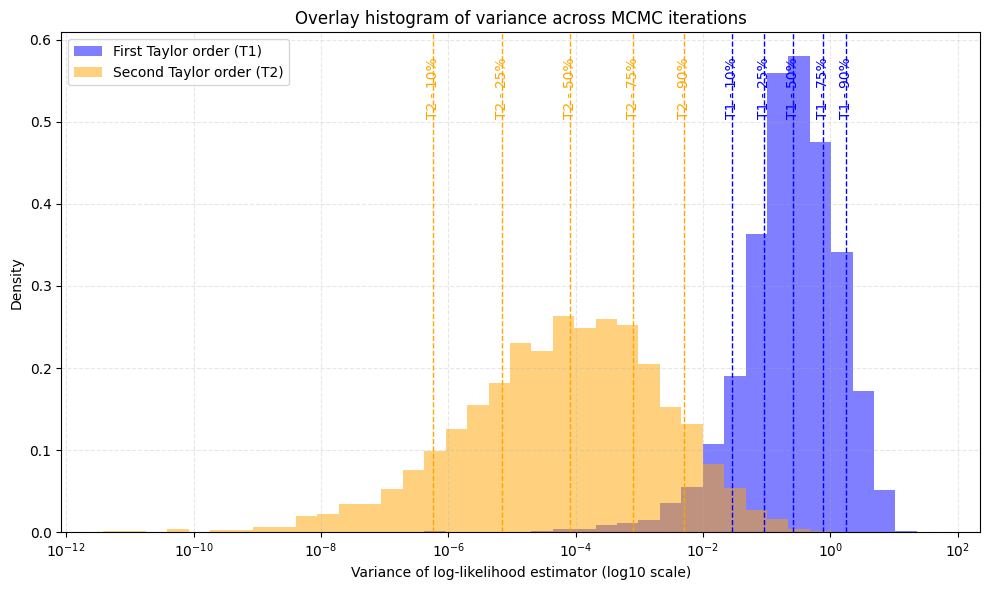

In [38]:
# dữ liệu đã là log10 variance
order1_var = np.log10(sigma2_lhat_samples1)
order2_var = np.log10(sigma2_lhat_samples)

# Kiểm tra range của dữ liệu trước
min_val = min(np.min(order1_var), np.min(order2_var))
max_val = max(np.max(order1_var), np.max(order2_var))

# Mở rộng bins để bao phủ toàn bộ dữ liệu (thêm margin)
bins = np.linspace(min_val+2, max_val + 0.5, 40)
percentiles = [10, 25, 50, 75, 90]

plt.figure(figsize=(10, 6))
plt.hist(order1_var, bins=bins, density=True, alpha=0.5,
         color="blue", label="First Taylor order (T1)")
plt.hist(order2_var, bins=bins, density=True, alpha=0.5,
         color="orange", label="Second Taylor order (T2)")

y_text = plt.gca().get_ylim()[1] * 0.95
for p in percentiles:
    r1_val = np.percentile(order1_var, p)
    t1_val = np.percentile(order2_var, p)
    plt.axvline(r1_val, color="blue", linestyle="--", linewidth=1)
    plt.text(r1_val, y_text, f"T1 - {p}%", color="blue",
             rotation=90, va="top", ha="center")
    plt.axvline(t1_val, color="orange", linestyle="--", linewidth=1)
    plt.text(t1_val, y_text, f"T2 - {p}%", color="orange",
             rotation=90, va="top", ha="center")

# Format x-axis để hiển thị dạng 10^x
ax = plt.gca()
xticks = ax.get_xticks()
xtick_labels = [f'$10^{{{int(x)}}}$' if x == int(x) else f'$10^{{{x:.1f}}}$' for x in xticks]
ax.set_xticklabels(xtick_labels)

plt.xlabel("Variance of log-likelihood estimator (log10 scale)")
plt.ylabel("Density")
plt.title("Overlay histogram of variance across MCMC iterations")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()